# Notebook 01 — Tiền xử lý dữ liệu

**Mục đích:** Làm sạch dữ liệu thô, xử lý giá trị thiếu, bất thường và tổng hợp về PM2.5 trung bình ngày.

**Đầu vào:** `data/raw/*.csv`  
**Đầu ra:** `data/processed/clean_data.csv`


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processor import load_raw, preprocess, save_clean, data_quality_report
from src.config import TARGET_COL, CLEAN_DATA_PATH

print('✅ Import thành công')

✅ Import thành công


## 1. Đọc dữ liệu thô

In [2]:
df_raw = load_raw()
print(f'Số bản ghi thô: {len(df_raw):,}')
print(f'Các cột: {list(df_raw.columns)}')
display(df_raw.head())

2026-08-05 20:47:15,970 [INFO] Đọc file: 2022.csv
2026-08-05 20:47:15,983 [INFO] Đọc file: 2023.csv
2026-08-05 20:47:15,998 [INFO] Đọc file: 2024.csv
2026-08-05 20:47:16,011 [INFO] Đọc file: 2025.csv
2026-08-05 20:47:16,021 [INFO] Tổng số bản ghi thô: 30,341


Số bản ghi thô: 30,341
Các cột: ['local time', 'utc time', 'city', 'country code', 'timezone', 'aqi', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative humidity', 'temperature', 'uv index', 'wind speed']


,local time,utc time,city,country code,timezone,aqi,co,no2,o3,pm10,pm25,so2,clouds,precipitation,pressure,relative humidity,temperature,uv index,wind speed
0,2022-01-13 00:00:00,2022-01-12T17:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,180.0,381.3,16.7,86.7,109.3,77.67,54.7,100,0.0,1019,93,17.0,0.0,1.22
1,2022-01-13 01:00:00,2022-01-12T18:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,181.0,389.8,17.0,87.0,111.0,79.00,59.0,100,0.0,1019,97,16.8,0.0,1.33
2,2022-01-13 02:00:00,2022-01-12T19:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,178.0,385.0,16.0,87.3,107.3,76.33,58.7,91,0.0,1019,97,16.4,0.0,1.44
3,2022-01-13 03:00:00,2022-01-12T20:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,174.0,380.1,15.0,87.7,103.7,73.67,58.3,83,0.0,1019,97,16.1,0.0,3.10
4,2022-01-13 04:00:00,2022-01-12T21:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,171.0,375.3,14.0,88.0,100.0,71.00,58.0,75,0.0,1018,97,15.7,0.0,1.66


## 2. Kiểm tra dữ liệu thiếu (trước xử lý)

In [3]:
missing_info = df_raw.isnull().sum().to_frame('Số thiếu')
missing_info['Tỷ lệ (%)'] = (df_raw.isnull().mean() * 100).round(2)
display(missing_info[missing_info['Số thiếu'] > 0])

,Số thiếu,Tỷ lệ (%)
aqi,2,0.01
co,74,0.24
no2,74,0.24
o3,74,0.24
pm10,2,0.01
pm25,2,0.01
so2,74,0.24


## 3. Tiền xử lý — làm sạch và tổng hợp ngày

In [4]:
df_clean = preprocess(df_raw)
print(f'\nSố ngày sau làm sạch: {len(df_clean):,}')
print(f'Khoảng thời gian: {df_clean.index.min().date()} → {df_clean.index.max().date()}')
display(df_clean.head(10))

2026-08-05 20:47:16,102 [INFO] Loại 0 hàng do thời gian không hợp lệ.
2026-08-05 20:47:16,126 [INFO] Nội suy: 1 giá trị thiếu đã được điền; 0 vẫn còn thiếu.
2026-08-05 20:47:16,127 [INFO] Dữ liệu sau xử lý: 1,265 ngày (2022-01-13 → 2025-06-30)



Số ngày sau làm sạch: 1,265
Khoảng thời gian: 2022-01-13 → 2025-06-30


,PM2.5
date,
2022-01-13,75.319583
2022-01-14,96.333333
2022-01-15,106.416667
2022-01-16,63.527917
2022-01-17,41.610833
2022-01-18,62.694583
2022-01-19,92.013750
2022-01-20,99.541667
2022-01-21,77.847500


## 4. Báo cáo chất lượng dữ liệu

In [5]:
report = data_quality_report(df_raw, df_clean)
display(report)

,Chỉ số,Trước xử lý,Sau xử lý
0,Số bản ghi,30341,1265
1,Giá trị PM2.5 thiếu,N/A,0
2,Giá trị PM2.5 âm,N/A,0
3,Bản ghi trùng,0,0


## 5. Thống kê mô tả PM2.5

In [6]:
desc = df_clean[TARGET_COL].describe().to_frame('PM2.5 (μg/m³)')
desc.index = ['Số quan sát', 'Trung bình', 'Độ lệch chuẩn', 'Min', 'Q25', 'Trung vị', 'Q75', 'Max']
display(desc.round(2))

,PM2.5 (μg/m³)
Số quan sát,1265.00
Trung bình,50.77
Độ lệch chuẩn,32.69
Min,2.33
Q25,28.97
Trung vị,41.50
Q75,62.69
Max,261.01


## 6. Kiểm tra giá trị thiếu còn lại và vẽ nhanh

Giá trị thiếu còn lại: 0


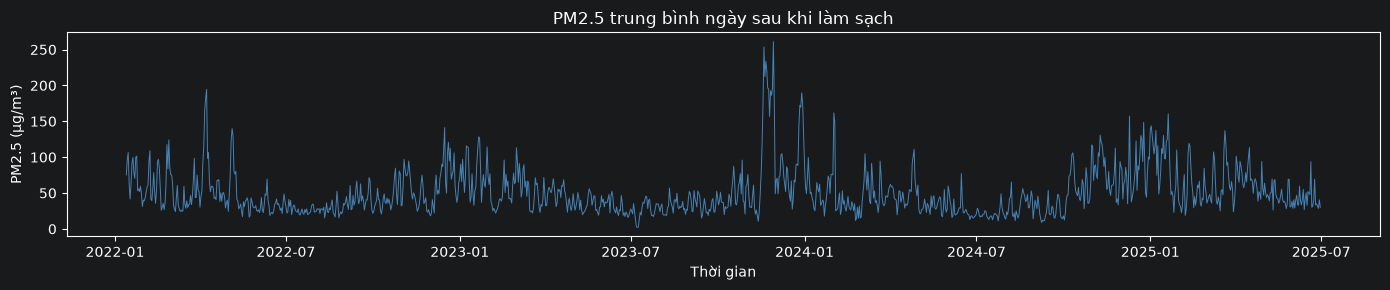

In [7]:
remaining_na = df_clean[TARGET_COL].isna().sum()
print(f'Giá trị thiếu còn lại: {remaining_na}')

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_clean.index, df_clean[TARGET_COL], linewidth=0.7, color='steelblue')
ax.set_title('PM2.5 trung bình ngày sau khi làm sạch')
ax.set_xlabel('Thời gian')
ax.set_ylabel('PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

## 7. Lưu dữ liệu đã làm sạch

In [8]:
save_clean(df_clean)
print(f'✅ Đã lưu: {CLEAN_DATA_PATH}')

2026-08-05 20:47:16,384 [INFO] Đã lưu dữ liệu sạch tại: D:\DuAn\QuanLyBuiMinPM25\data\processed\clean_data.csv


✅ Đã lưu: D:\DuAn\QuanLyBuiMinPM25\data\processed\clean_data.csv


---
✅ **Hoàn thành!** Chạy tiếp `02_eda.ipynb`.